# =============================================================================
# NETWORK TRAFFIC ANALYSIS - EXPLORATORY DATA ANALYSIS
# =============================================================================

## Network Traffic Analysis

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project aims to analyze network traffic data to understand patterns, detect anomalies, and identify potential cyber attacks. The analysis will examine how different network protocols, services, and connection states relate to security threats.

### 2) Data Collection
- Dataset appears to be network traffic data with 45 columns and multiple rows
- The data includes features like protocol, service, packet counts, bytes transferred, and attack classifications

### 2.1 Import Data and Required Packages
#### Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Assuming the data is already loaded as df
# df = pd.read_csv('network_traffic_data.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 records:")
df.head()

Dataset shape: (175341, 45)

First 5 records:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


### 2.2 Dataset information
Based on the provided data sample, here are the key features:

- **id**: Connection identifier
- **dur**: Duration of the connection
- **proto**: Protocol used (tcp, udp, etc.)
- **service**: Network service (ftp, http, etc.)
- **state**: Connection state (FIN, CON, etc.)
- **spkts**: Source to destination packet count
- **dpkts**: Destination to source packet count  
- **sbytes**: Source to destination bytes
- **dbytes**: Destination to source bytes
- **rate**: Connection rate
- **attack_cat**: Attack category
- **label**: Binary label (0: Normal, 1: Attack)

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [7]:
print("Missing values in each column:")
print(df.isna().sum())
print(f"\nTotal missing values: {df.isna().sum().sum()}")

Missing values in each column:
id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_

### 3.2 Check Duplicates

In [8]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


### 3.3 Check data types

In [9]:
print("Data types information:")
df.info()

Data types information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 n

### 3.4 Checking the number of unique values of each column

In [10]:
print("Number of unique values in each column:")
print(df.nunique())

Number of unique values in each column:
id                   175341
dur                   74039
proto                   133
service                  13
state                     9
spkts                   480
dpkts                   443
sbytes                 7214
dbytes                 6660
rate                  76991
sttl                     11
dttl                      6
sload                 80885
dload                 77474
sloss                   409
dloss                   370
sinpkt                76161
dinpkt                74245
sjit                  77532
djit                  76831
swin                     13
stcpb                 75265
dtcpb                 75089
dwin                      7
tcprtt                43319
synack                40142
ackdat                37708
smean                  1357
dmean                  1328
trans_depth              11
response_body_len      2386
ct_srv_src               52
ct_state_ttl              5
ct_dst_ltm               50
ct_src_d

### 3.5 Check statistics of data set

In [11]:
print("Statistical summary of numerical features:")
df.describe()

Statistical summary of numerical features:


,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


### 3.6 Check statistics of categorical data

In [12]:
print("Statistical summary of categorical features:")
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols].describe()

Statistical summary of categorical features:


,proto,service,state,attack_cat
count,175341,175341,175341,175341
unique,133,13,9,10
top,tcp,-,INT,Normal
freq,79946,94168,82275,56000


### 3.7 Exploring Data

In [13]:
print("Categories in 'proto' variable:     ", end=" ")
print(df['proto'].unique())

print("Categories in 'service' variable:  ", end=" ")
print(df['service'].unique())

print("Categories in 'state' variable:     ", end=" ")
print(df['state'].unique())

print("Categories in 'attack_cat' variable:", end=" ")
print(df['attack_cat'].unique())

print("Categories in 'label' variable:     ", end=" ")
print(df['label'].unique())

Categories in 'proto' variable:      ['tcp' 'udp' 'arp' 'ospf' 'icmp' 'igmp' 'rtp' 'ddp' 'ipv6-frag' 'cftp'
 'wsn' 'pvp' 'wb-expak' 'mtp' 'pri-enc' 'sat-mon' 'cphb' 'sun-nd' 'iso-ip'
 'xtp' 'il' 'unas' 'mfe-nsp' '3pc' 'ipv6-route' 'idrp' 'bna' 'swipe'
 'kryptolan' 'cpnx' 'rsvp' 'wb-mon' 'vmtp' 'ib' 'dgp' 'eigrp' 'ax.25'
 'gmtp' 'pnni' 'sep' 'pgm' 'idpr-cmtp' 'zero' 'rvd' 'mobile' 'narp' 'fc'
 'pipe' 'ipcomp' 'ipv6-no' 'sat-expak' 'ipv6-opts' 'snp' 'ipcv'
 'br-sat-mon' 'ttp' 'tcf' 'nsfnet-igp' 'sprite-rpc' 'aes-sp3-d' 'sccopmce'
 'sctp' 'qnx' 'scps' 'etherip' 'aris' 'pim' 'compaq-peer' 'vrrp' 'iatp'
 'stp' 'l2tp' 'srp' 'sm' 'isis' 'smp' 'fire' 'ptp' 'crtp' 'sps'
 'merit-inp' 'idpr' 'skip' 'any' 'larp' 'ipip' 'micp' 'encap' 'ifmp'
 'tp++' 'a/n' 'ipv6' 'i-nlsp' 'ipx-n-ip' 'sdrp' 'tlsp' 'gre' 'mhrp' 'ddx'
 'ippc' 'visa' 'secure-vmtp' 'uti' 'vines' 'crudp' 'iplt' 'ggp' 'ip'
 'ipnip' 'st2' 'argus' 'bbn-rcc' 'egp' 'emcon' 'igp' 'nvp' 'pup' 'xnet'
 'chaos' 'mux' 'dcn' 'hmp' 'prm' 'trunk-1' 'xn

In [14]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 41 numerical features : ['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label']

We have 4 categorical features : ['proto', 'service', 'state', 'attack_cat']


### 3.8 Adding derived features for better analysis

In [15]:
# Calculate total packets and bytes
df['total_packets'] = df['spkts'] + df['dpkts']
df['total_bytes'] = df['sbytes'] + df['dbytes']
df['packet_size_ratio'] = df['sbytes'] / (df['spkts'] + 1)  # Adding 1 to avoid division by zero

print("Added derived features:")
print(df[['total_packets', 'total_bytes', 'packet_size_ratio']].head())

Added derived features:
   total_packets  total_bytes  packet_size_ratio
0             10          430          36.857143
1             52        42748          48.933333
2             24        13550          40.444444
3             24         1398          48.307692
4             16          802          48.545455


In [16]:
# Check attack distribution
attack_counts = df['attack_cat'].value_counts()
label_counts = df['label'].value_counts()

print("Attack category distribution:")
print(attack_counts)
print(f"\nLabel distribution (0: Normal, 1: Attack):")
print(label_counts)
print(f"\nAttack percentage: {(label_counts[1] / len(df) * 100):.2f}%")

Attack category distribution:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Label distribution (0: Normal, 1: Attack):
label
1    119341
0     56000
Name: count, dtype: int64

Attack percentage: 68.06%


### 4. Exploring Data (Visualization)

#### 4.1 Visualize attack distribution

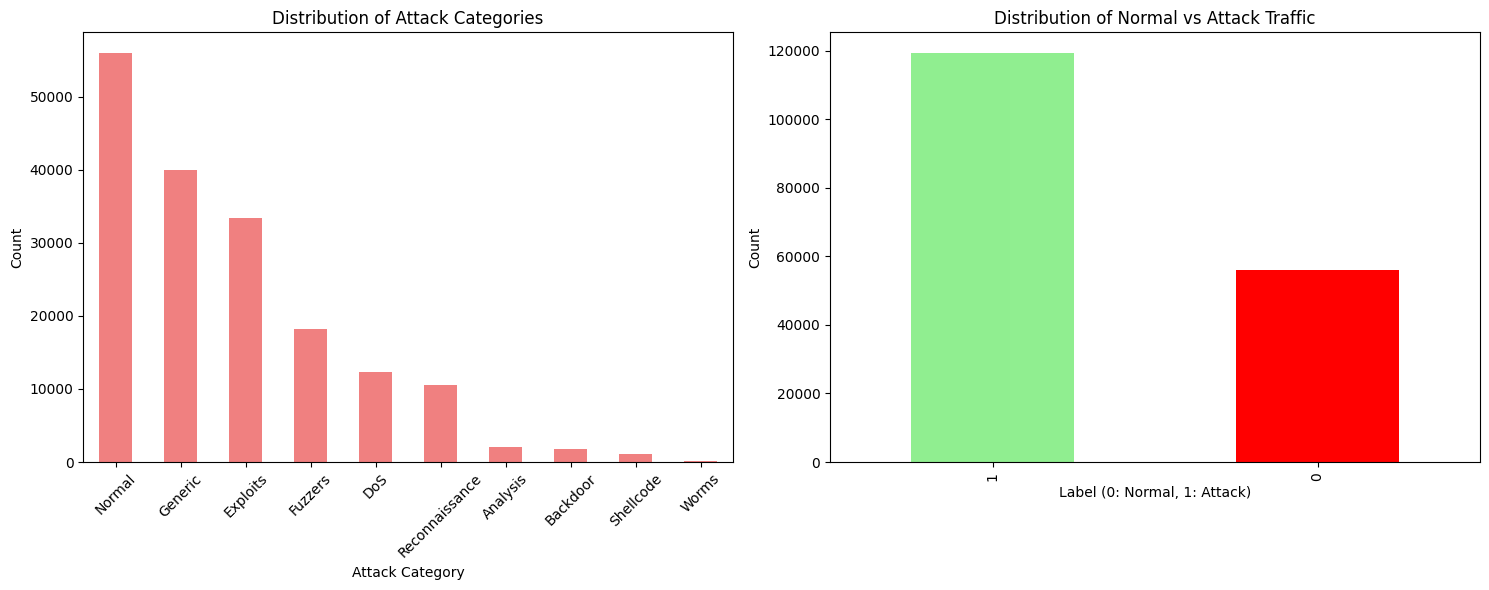

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Attack categories
plt.subplot(1, 2, 1)
attack_counts.plot(kind='bar', color='lightcoral')
plt.title('Distribution of Attack Categories')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Binary labels
plt.subplot(1, 2, 2)
label_counts.plot(kind='bar', color=['lightgreen', 'red'])
plt.title('Distribution of Normal vs Attack Traffic')
plt.xlabel('Label (0: Normal, 1: Attack)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### 4.2 Protocol and Service Analysis

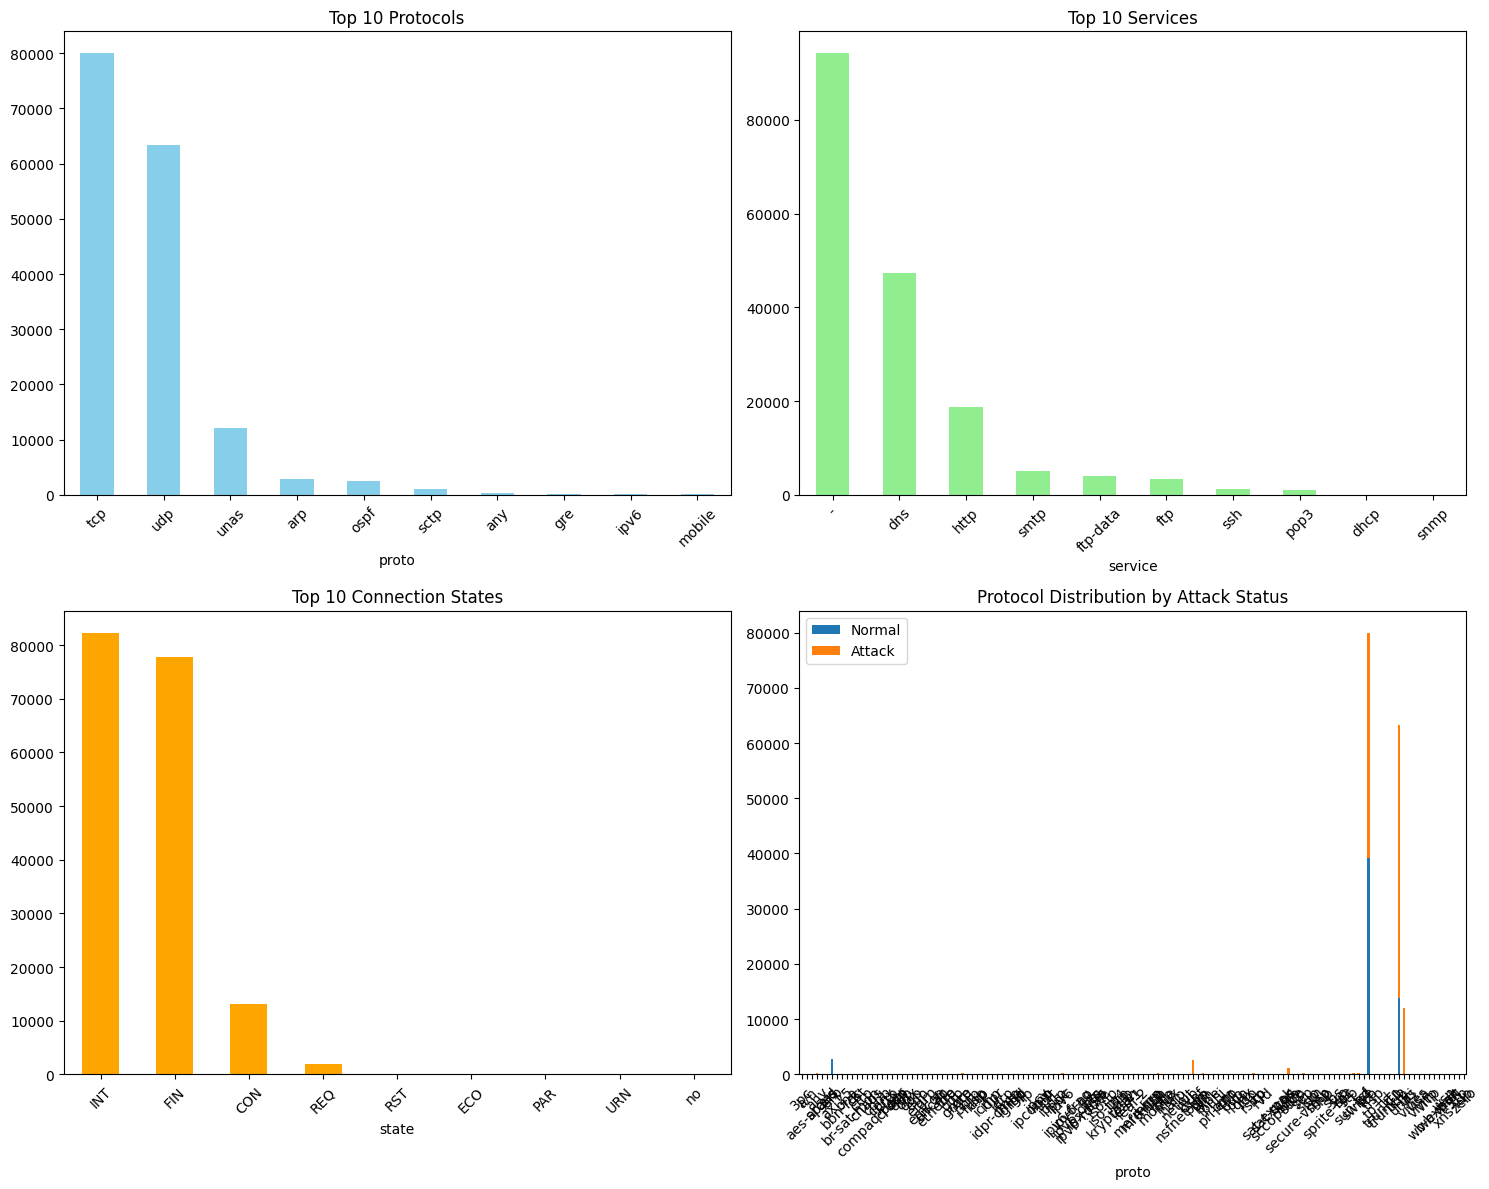

In [18]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Protocol distribution
plt.subplot(2, 2, 1)
df['proto'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Protocols')
plt.xticks(rotation=45)

# Service distribution
plt.subplot(2, 2, 2)
df['service'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title('Top 10 Services')
plt.xticks(rotation=45)

# Connection state distribution
plt.subplot(2, 2, 3)
df['state'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Connection States')
plt.xticks(rotation=45)

# Protocol vs Attack
plt.subplot(2, 2, 4)
protocol_attack = pd.crosstab(df['proto'], df['label'])
protocol_attack.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Protocol Distribution by Attack Status')
plt.xticks(rotation=45)
plt.legend(['Normal', 'Attack'])

plt.tight_layout()
plt.show()

#### 4.3 Numerical Features Distribution

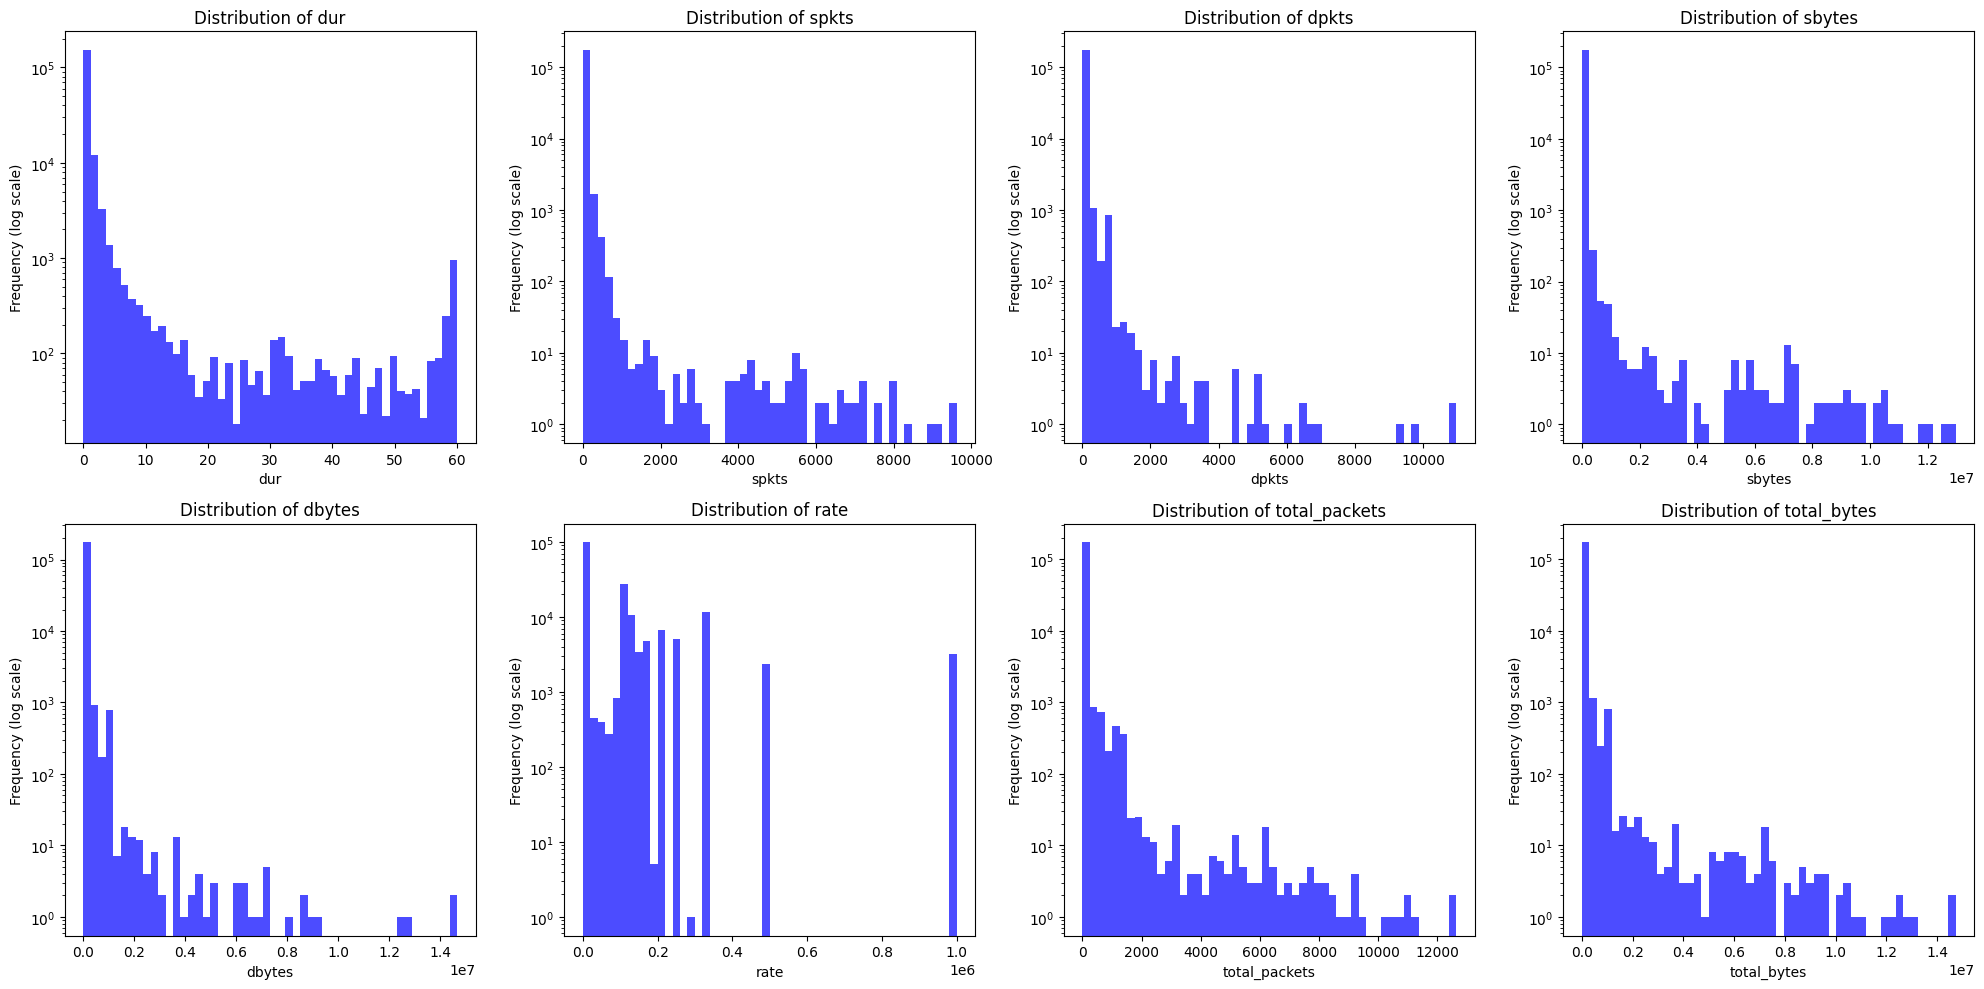

In [19]:
# Select key numerical features for analysis
key_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'total_packets', 'total_bytes']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    # Use log scale for better visualization of skewed data
    axes[i].hist(df[feature], bins=50, alpha=0.7, color='blue', log=True)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

#### 4.4 Correlation Analysis

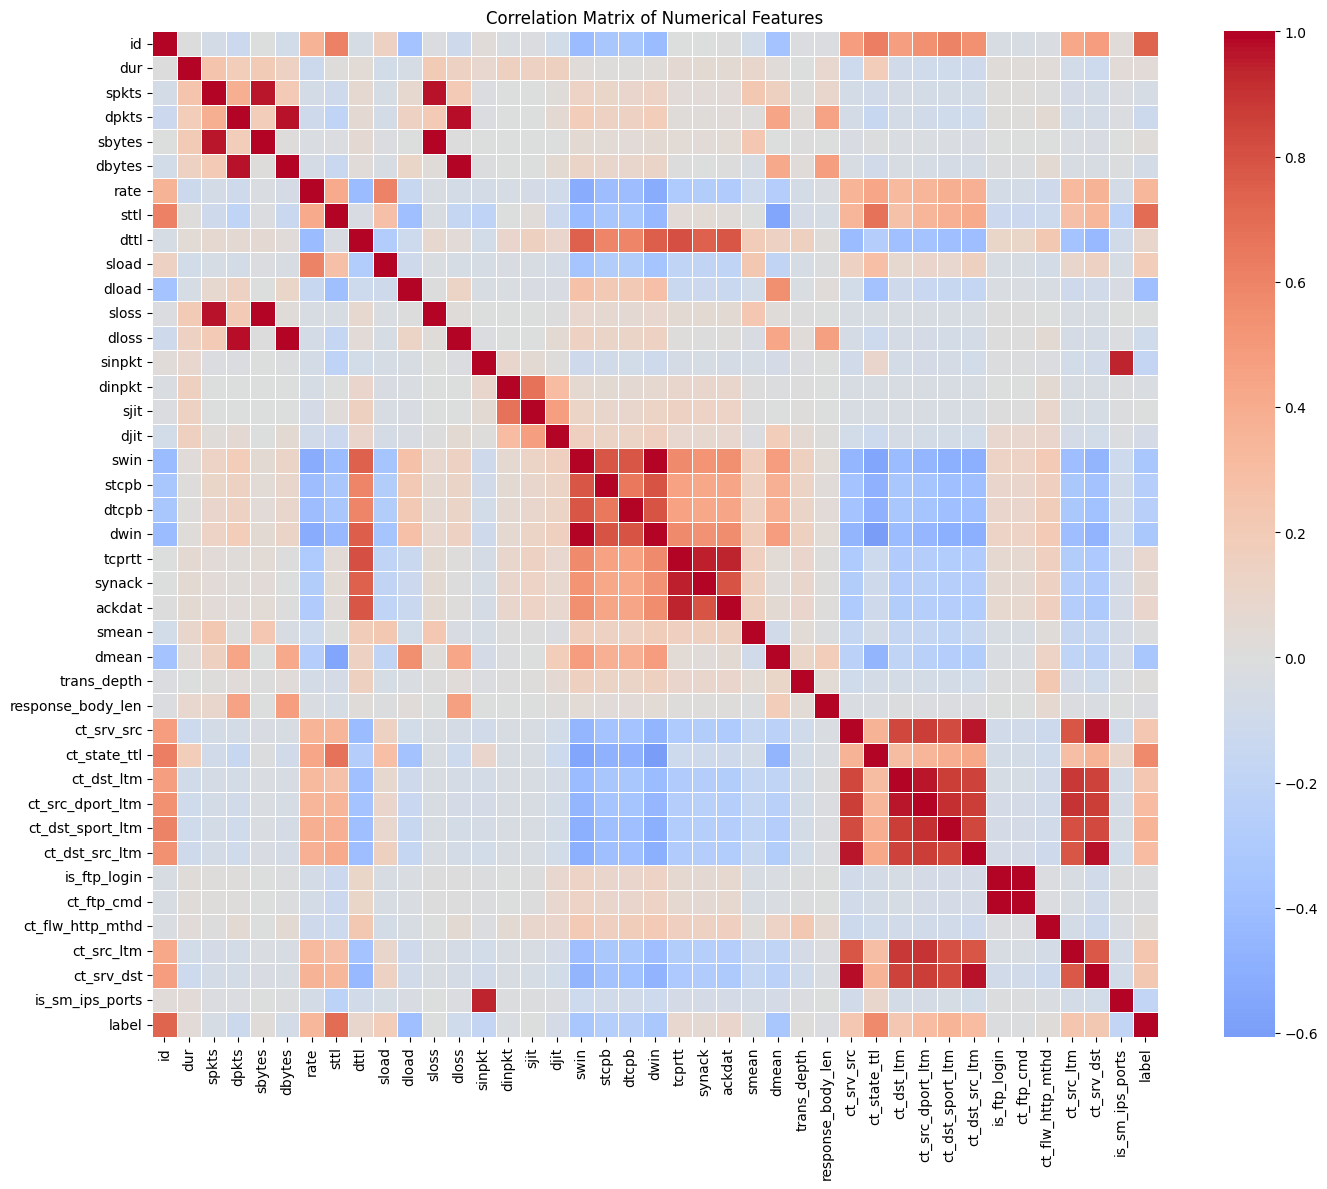

Top 10 features correlated with label:
label               1.000000
id                  0.727173
sttl                0.692741
ct_state_ttl        0.577704
ct_dst_sport_ltm    0.357213
rate                0.337979
ct_src_dport_ltm    0.305579
ct_dst_src_ltm      0.303855
ct_src_ltm          0.238225
ct_dst_ltm          0.229887
Name: label, dtype: float64


In [20]:

# Calculate correlation matrix for numerical features
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

# Show top correlations with label
label_correlations = correlation_matrix['label'].sort_values(ascending=False)
print("Top 10 features correlated with label:")
print(label_correlations.head(10))

#### 4.5 Attack Patterns Analysis

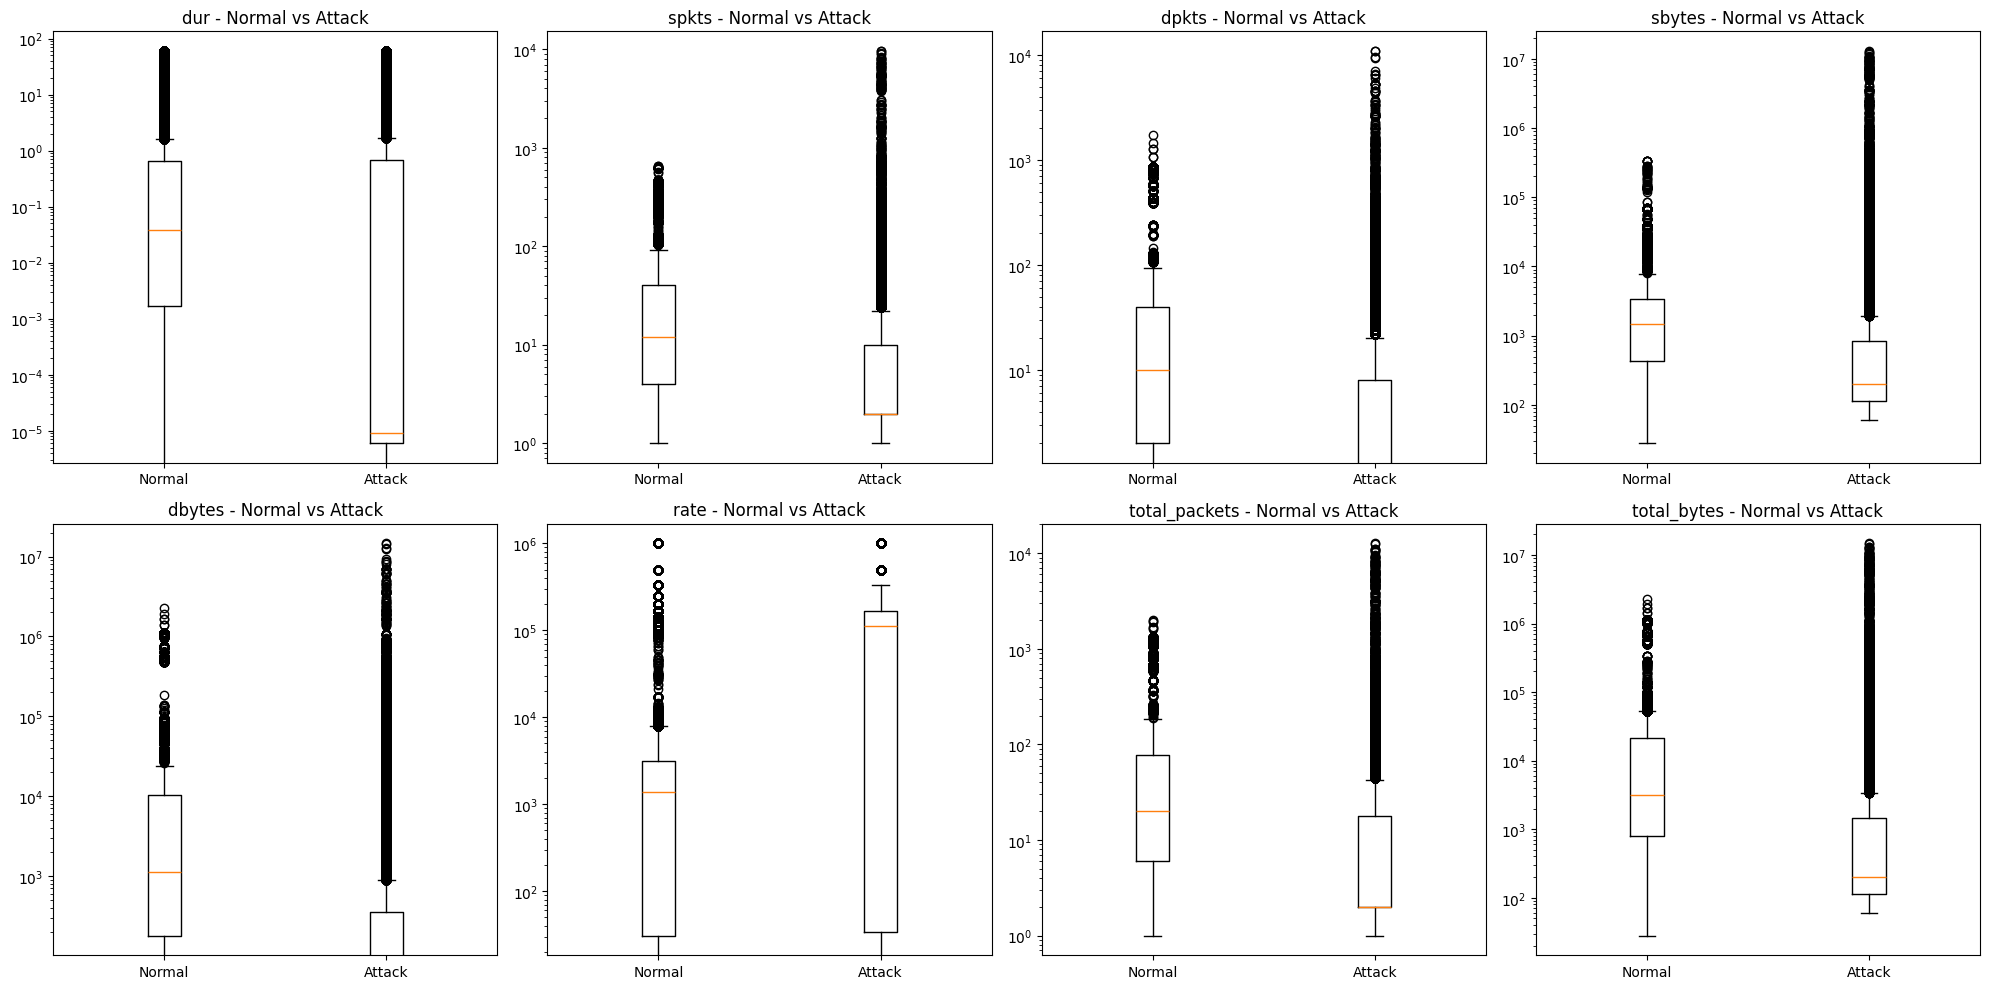

In [21]:

# Compare numerical features between normal and attack traffic
comparison_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'total_packets', 'total_bytes']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(comparison_features):
    # Create box plots for normal vs attack
    normal_data = df[df['label'] == 0][feature]
    attack_data = df[df['label'] == 1][feature]
    
    # Use log scale for better visualization
    data_to_plot = [normal_data, attack_data]
    axes[i].boxplot(data_to_plot, labels=['Normal', 'Attack'])
    axes[i].set_title(f'{feature} - Normal vs Attack')
    axes[i].set_yscale('log')  # Log scale for better visualization

plt.tight_layout()
plt.show()

#### 4.6 Protocol-Service Analysis

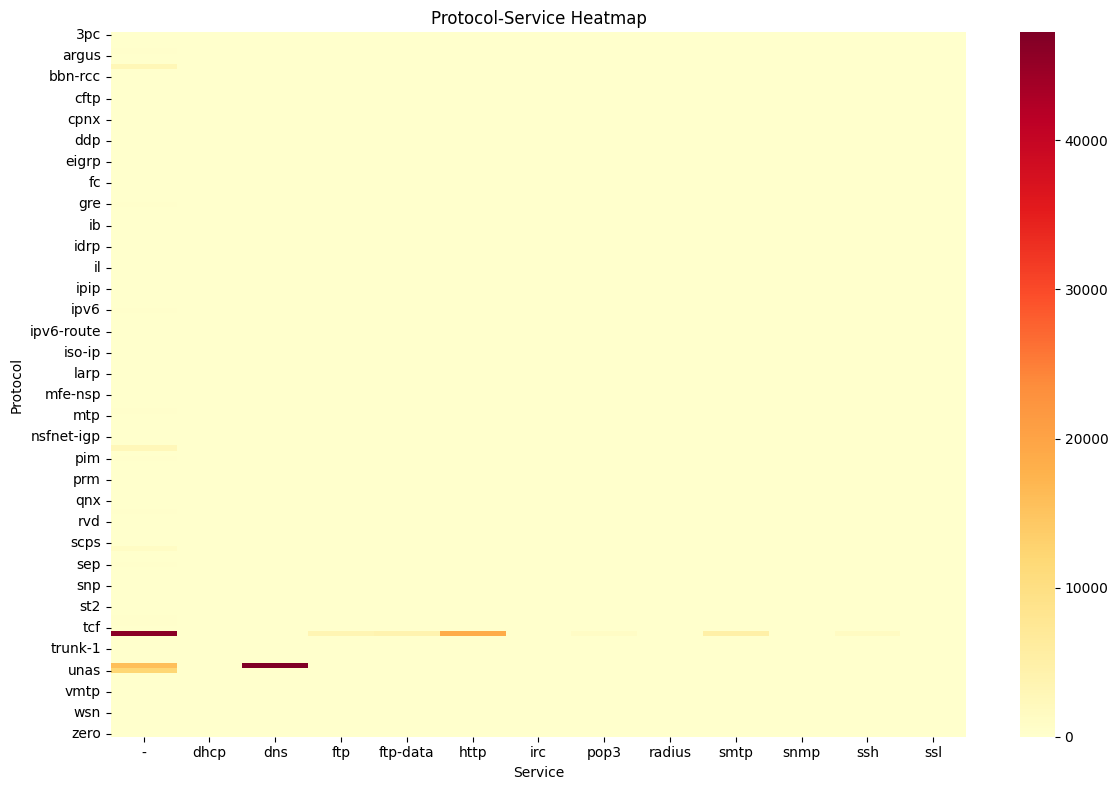

In [22]:

# Create cross-tabulation of protocol and service
protocol_service = pd.crosstab(df['proto'], df['service'])
plt.figure(figsize=(12, 8))
sns.heatmap(protocol_service, cmap='YlOrRd', annot=False)
plt.title('Protocol-Service Heatmap')
plt.xlabel('Service')
plt.ylabel('Protocol')
plt.tight_layout()
plt.show()

#### 4.7 Duration Analysis by Attack Type

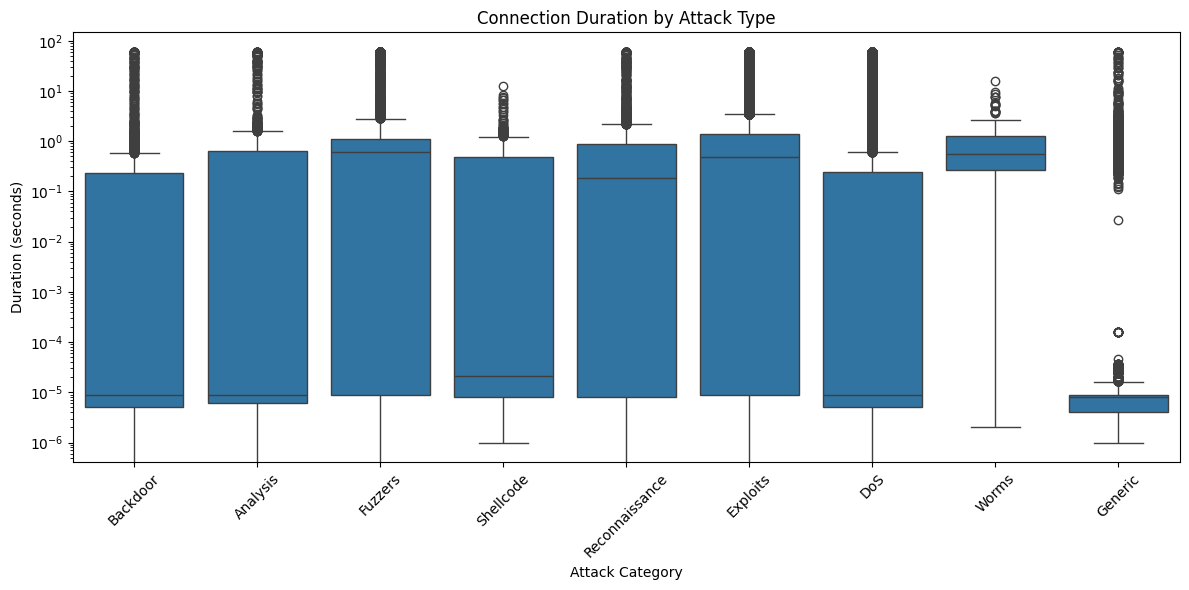

In [23]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='attack_cat', y='dur', data=df[df['label'] == 1])
plt.title('Connection Duration by Attack Type')
plt.xlabel('Attack Category')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.yscale('log')  # Log scale for better visualization
plt.tight_layout()
plt.show()

#### 4.8 Packet and Byte Analysis

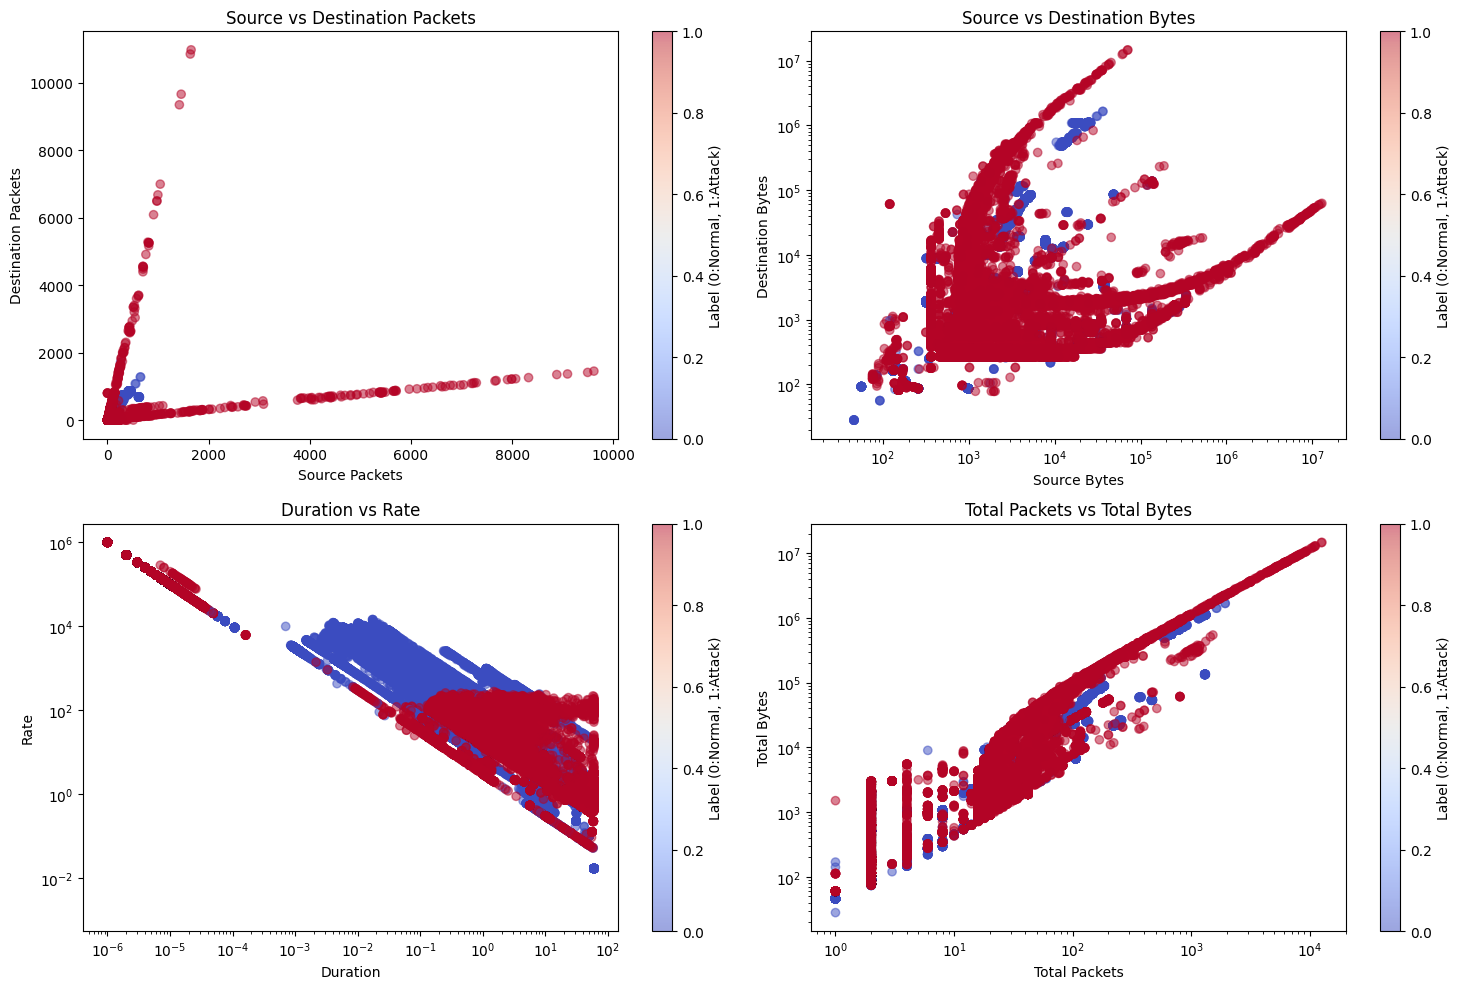

In [24]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Source vs Destination packets
plt.subplot(2, 2, 1)
plt.scatter(df['spkts'], df['dpkts'], alpha=0.5, c=df['label'], cmap='coolwarm')
plt.xlabel('Source Packets')
plt.ylabel('Destination Packets')
plt.title('Source vs Destination Packets')
plt.colorbar(label='Label (0:Normal, 1:Attack)')

# Source vs Destination bytes
plt.subplot(2, 2, 2)
plt.scatter(df['sbytes'], df['dbytes'], alpha=0.5, c=df['label'], cmap='coolwarm')
plt.xlabel('Source Bytes')
plt.ylabel('Destination Bytes')
plt.title('Source vs Destination Bytes')
plt.colorbar(label='Label (0:Normal, 1:Attack)')
plt.xscale('log')
plt.yscale('log')

# Rate vs Duration
plt.subplot(2, 2, 3)
plt.scatter(df['dur'], df['rate'], alpha=0.5, c=df['label'], cmap='coolwarm')
plt.xlabel('Duration')
plt.ylabel('Rate')
plt.title('Duration vs Rate')
plt.colorbar(label='Label (0:Normal, 1:Attack)')
plt.xscale('log')
plt.yscale('log')

# Total packets vs Total bytes
plt.subplot(2, 2, 4)
plt.scatter(df['total_packets'], df['total_bytes'], alpha=0.5, c=df['label'], cmap='coolwarm')
plt.xlabel('Total Packets')
plt.ylabel('Total Bytes')
plt.title('Total Packets vs Total Bytes')
plt.colorbar(label='Label (0:Normal, 1:Attack)')
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.show()

#### 4.9 Connection State Analysis

<Figure size 1000x600 with 0 Axes>

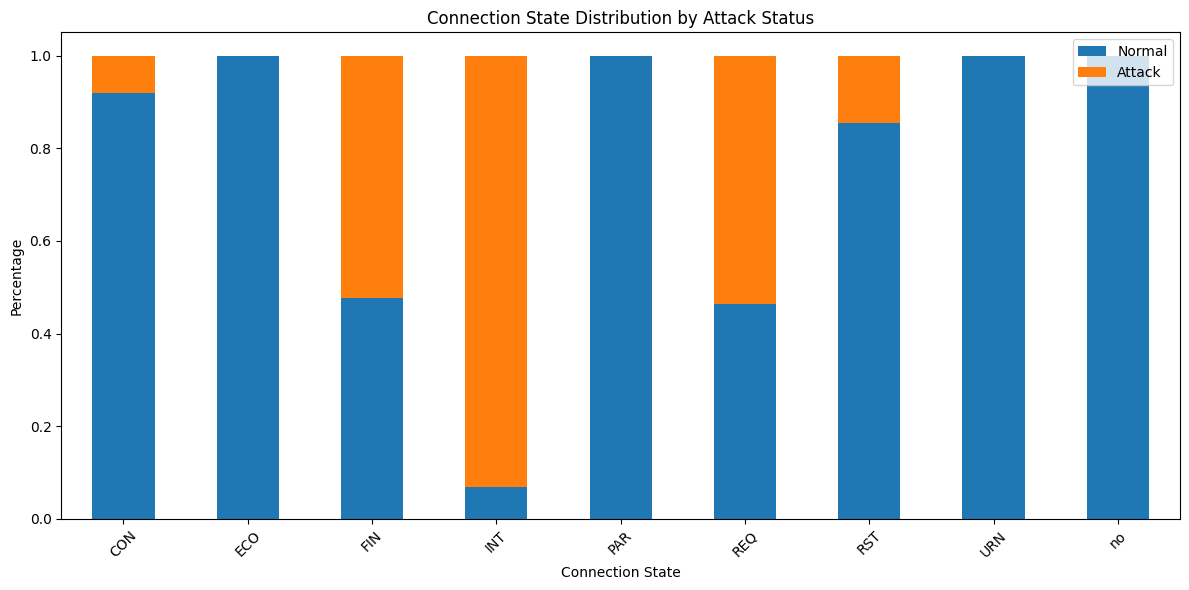

In [25]:

plt.figure(figsize=(10, 6))
state_attack = pd.crosstab(df['state'], df['label'])
state_attack_percentage = state_attack.div(state_attack.sum(1), axis=0)

state_attack_percentage.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Connection State Distribution by Attack Status')
plt.xlabel('Connection State')
plt.ylabel('Percentage')
plt.legend(['Normal', 'Attack'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4.10 Feature Importance Analysis

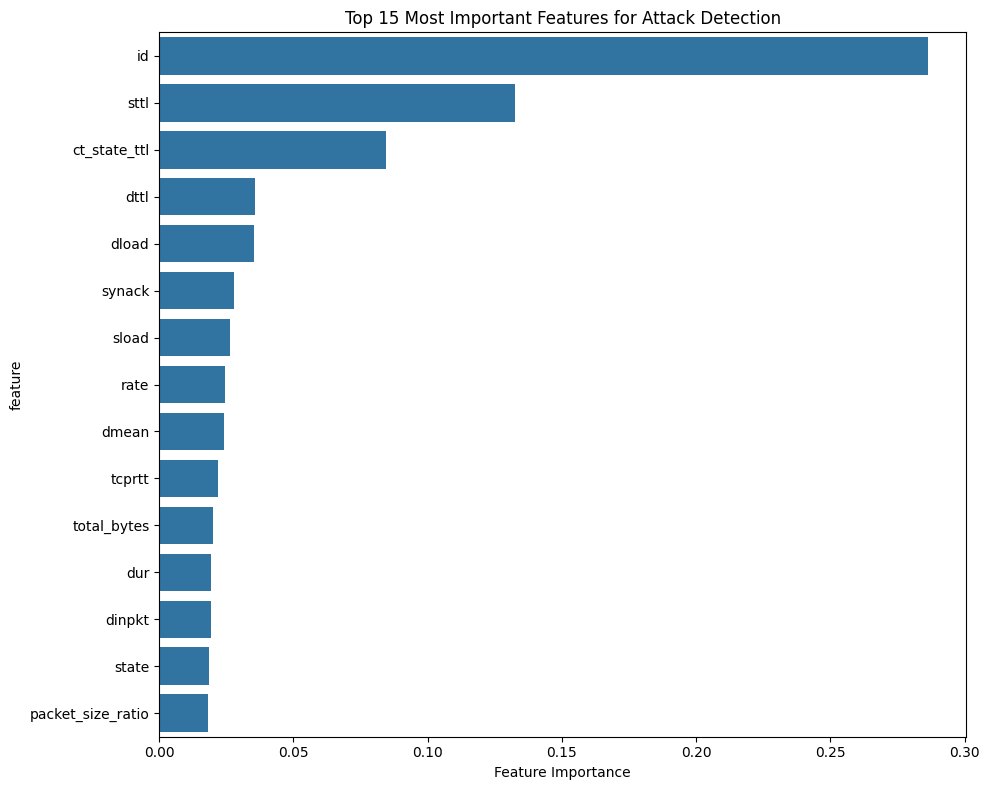

Top 10 most important features:
         feature  importance
0             id    0.286311
10          sttl    0.132556
32  ct_state_ttl    0.084590
11          dttl    0.035846
13         dload    0.035425
25        synack    0.027865
12         sload    0.026529
9           rate    0.024356
28         dmean    0.024132
24        tcprtt    0.021896


In [26]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Prepare data for feature importance
df_encoded = df.copy()

# Encode categorical variables
label_encoders = {}
for col in categorical_features:
    if col != 'attack_cat':  # We'll keep attack_cat as is for now
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Separate features and target
X = df_encoded.drop(['attack_cat', 'label'], axis=1)
y = df_encoded['label']

# Train Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Most Important Features for Attack Detection')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feature_importance.head(10))

#### 4.11 Time-based Analysis (if timestamp available)

Time-based features found: []


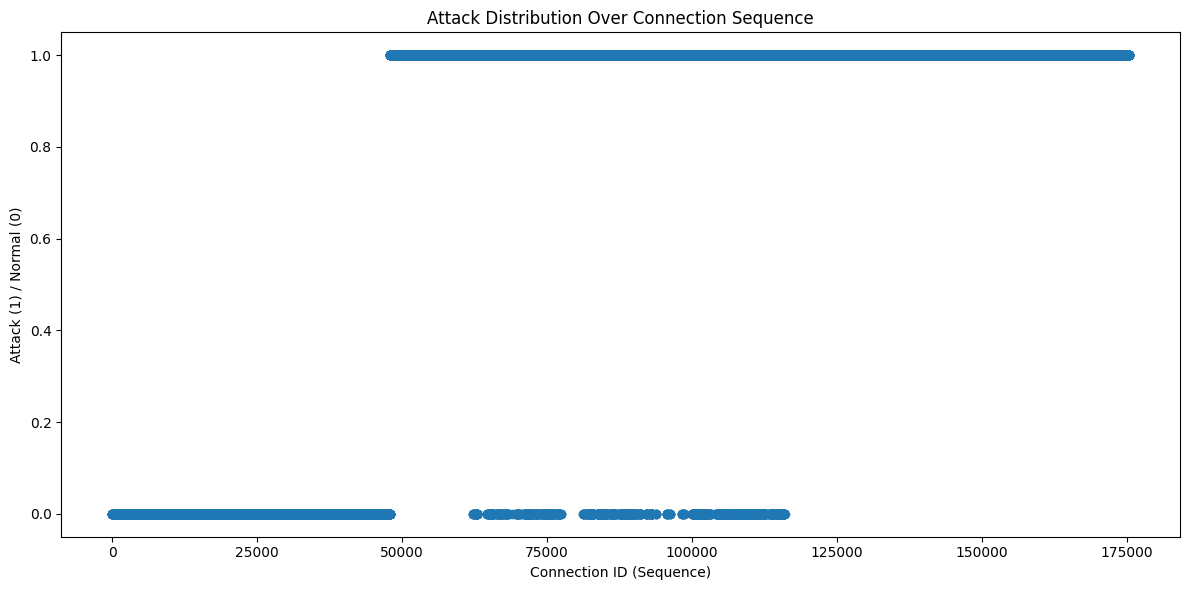

In [27]:

# Check if there's any time-based feature
time_based_features = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
print("Time-based features found:", time_based_features)

# If no explicit time feature, we can use id as proxy for connection sequence
if 'id' in df.columns:
    plt.figure(figsize=(12, 6))
    plt.scatter(df['id'], df['label'], alpha=0.1)
    plt.xlabel('Connection ID (Sequence)')
    plt.ylabel('Attack (1) / Normal (0)')
    plt.title('Attack Distribution Over Connection Sequence')
    plt.tight_layout()
    plt.show()

#### 4.12 Multivariate Analysis using PairPlot

<Figure size 1200x1000 with 0 Axes>

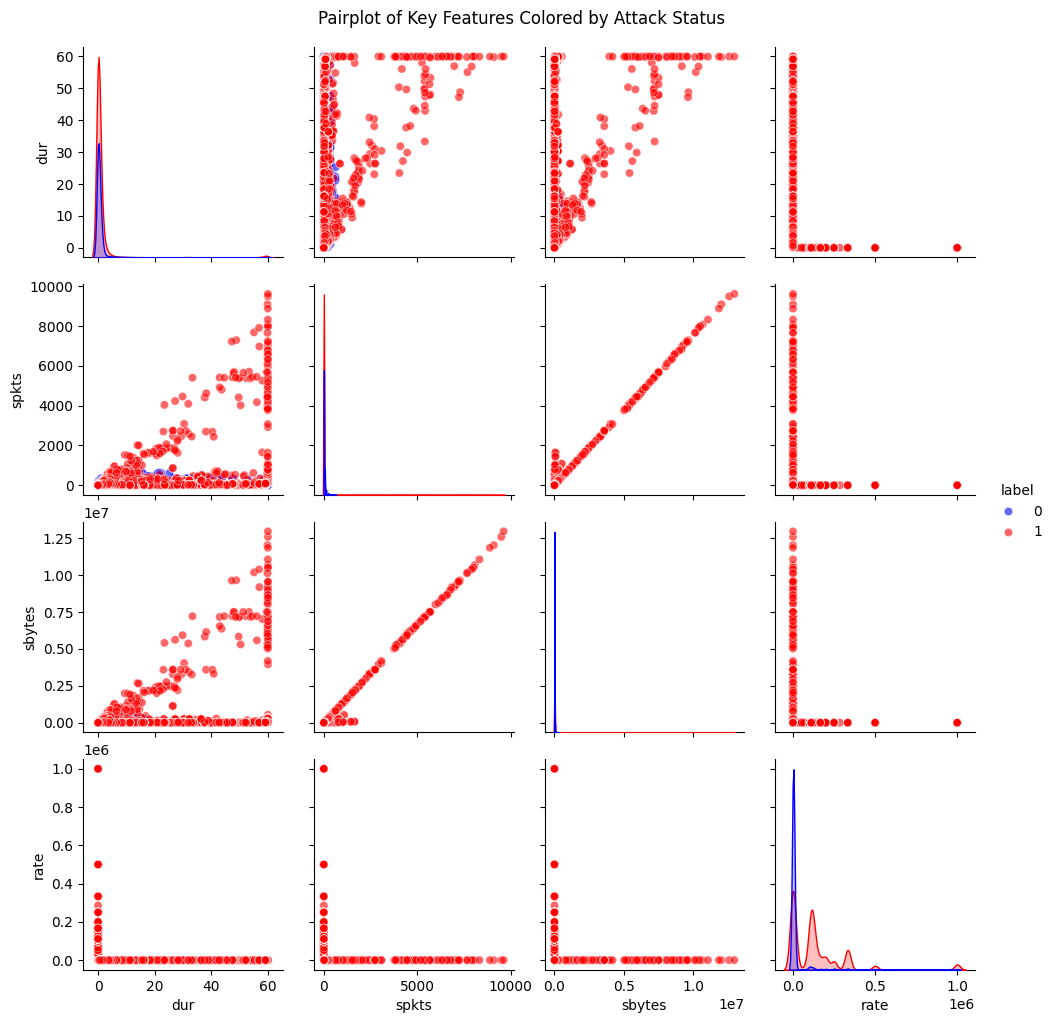

: 

In [ ]:

# Select key features for pairplot
key_features_pair = ['dur', 'spkts', 'sbytes', 'rate', 'label'][:5]  # Limit to 5 for performance

plt.figure(figsize=(12, 10))
sns.pairplot(df[key_features_pair], hue='label', palette={0: 'blue', 1: 'red'}, 
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Key Features Colored by Attack Status', y=1.02)
plt.show()

### 5. Key Insights and Conclusions

In [ ]:
print("="*50)
print("KEY INSIGHTS FROM EDA")
print("="*50)

# 1. Data Overview
print(f"1. DATASET OVERVIEW:")
print(f"   - Total records: {len(df)}")
print(f"   - Features: {len(df.columns)}")
print(f"   - Attack rate: {(df['label'].mean() * 100):.2f}%")

# 2. Attack Distribution
attack_dist = df['attack_cat'].value_counts()
print(f"\n2. ATTACK DISTRIBUTION:")
for attack, count in attack_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   - {attack}: {count} ({percentage:.2f}%)")

# 3. Protocol Analysis
print(f"\n3. PROTOCOL ANALYSIS:")
proto_attack_rate = df.groupby('proto')['label'].mean().sort_values(ascending=False)
print(f"   - Most dangerous protocol: {proto_attack_rate.index[0]} ({proto_attack_rate.iloc[0]*100:.1f}% attack rate)")

# 4. Service Analysis
print(f"\n4. SERVICE ANALYSIS:")
service_attack_rate = df.groupby('service')['label'].mean().sort_values(ascending=False)
print(f"   - Most dangerous service: {service_attack_rate.index[0]} ({service_attack_rate.iloc[0]*100:.1f}% attack rate)")

# 5. Key Differences
print(f"\n5. KEY DIFFERENCES BETWEEN NORMAL AND ATTACK TRAFFIC:")
normal_stats = df[df['label'] == 0][['dur', 'spkts', 'sbytes', 'rate']].median()
attack_stats = df[df['label'] == 1][['dur', 'spkts', 'sbytes', 'rate']].median()

for feature in ['dur', 'spkts', 'sbytes', 'rate']:
    normal_val = normal_stats[feature]
    attack_val = attack_stats[feature]
    ratio = attack_val / normal_val if normal_val > 0 else float('inf')
    print(f"   - {feature}: Normal={normal_val:.2f}, Attack={attack_val:.2f}, Ratio={ratio:.2f}x")

# 6. Feature Importance
print(f"\n6. MOST IMPORTANT FEATURES FOR DETECTION:")
top_features = feature_importance.head(5)
for _, row in top_features.iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

print("="*50)

### 6. Recommendations for Next Steps

In [ ]:
print("RECOMMENDATIONS FOR MODEL BUILDING:")
print("1. DATA PREPROCESSING:")
print("   - Handle categorical variables (proto, service, state) using encoding")
print("   - Normalize numerical features due to different scales")
print("   - Consider log transformation for highly skewed features")

print("\n2. FEATURE ENGINEERING:")
print("   - Use derived features like packet_size_ratio, total_packets, total_bytes")
print("   - Consider interaction terms between key features")
print("   - Focus on top important features identified in EDA")

print("\n3. MODEL SELECTION:")
print("   - Binary classification: Random Forest, XGBoost, Neural Networks")
print("   - Multi-class classification for attack type prediction")
print("   - Consider anomaly detection algorithms for unknown attacks")

print("\n4. VALIDATION STRATEGY:")
print("   - Stratified sampling due to potential class imbalance")
print("   - Time-based split if temporal patterns exist")
print("   - Cross-validation for robust performance estimation")

print("\n5. PERFORMANCE METRICS:")
print("   - Focus on Recall (minimize false negatives)")
print("   - Monitor Precision (avoid too many false positives)")
print("   - Use F1-score for balanced evaluation")
print("   - Consider ROC-AUC for overall performance")